# Geometría + modelo elíptico desde input.ctl o parámetros Python

Este notebook crea la geometría de falla desde `input.ctl` (o dict de parámetros Python) y aplica el modelo elíptico de 7 parámetros.

## Flujo de trabajo (7 pasos)

1. **Parsear configuración:** Cargar `input.ctl` o usar parámetros Python directos
2. **Construir geometría base invariante:** Discretización de falla (subfallas, rigidez, área)
3. **Aplicar modelo elíptico (7 parámetros):** Mapeo de ruptura (tiempos + deslizamiento)
4. **Calcular momento escalar:** M₀ [N·m] y magnitud Mw desde el deslizamiento
5. **Convertir a Cartesianas locales:** Transformar lat/lon a x/y/z (Norte/Este/Profundidad)
6. **Visualizar geometría:** Planta (x-y) y sección transversal (x-z)
7. **Exportar para AXITRA:** Fuentes (subfallas) + estaciones al wrapper de Fortran

## Estructura de input.ctl (8 secciones)

| Sección | Propósito | Parámetros clave |
|---------|-----------|------------------|
| **1. Observed Data** | Ventana de tiempo, muestreo | t1, t2, Δt, Npts, unidades (despl./vel.) |
| **2. Source Position** | Ubicación y mecanismo focal | lat, lon, profundidad, strike, dip, rake |
| **3. Fault Plane** | Discretización de la falla | Lx, Ly (longitudes), Nx, Ny (subfallas) |
| **4. Ellipse & Freq** | Modelo elíptico + banda | freq1, freq2, t₀ (desplazamiento temporal) |
| **5. Inversion Params** | Rango de búsqueda (7 params) | a₁, a₂, θ, n_p, t_p, d_max, v_r |
| **6. Inversion Process** | Algoritmo NA/MC, iteraciones | SS1, SS_other, cells_resample |
| **7. Moment Tensor** | Full MT (opcional) | Mrr, Mtt, Mpp, Mrt, Mrp, Mtp |
| **8. Stations** | Red de estaciones | lat, lon, altura, nombre |
| **9. Velocity Model** | Capas 1D | espesor   , Vp, Vs, ρ, Qp, Qs |

### Parámetros del modelo elíptico (7)

Los parámetros que se invierten son:
- **a₁, a₂** [km]: Semi-ejes de la elipse
- **θ** [0,π]: Ángulo de rotación (fracción de π)
- **n_p** [0,1]: Posición fraccionaria en la falla
- **t_p** [0,2π]: Ángulo de iniciación (fracción de 2π)
- **d_max** [m]: Deslizamiento máximo
- **v_r** [km/s]: Velocidad de ruptura

## Dos enfoques: archivo vs. Python

Este notebook muestra ambos workflows:
- **Enfoque 1 (archivo):** Leer desde `input.ctl` (formato legible, predefinido)
- **Enfoque 2 (Python):** Parámetros como dict (programático, flexible)

In [5]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os
def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'kdellipspy').exists():
            return p
    raise FileNotFoundError('No se encontro PROJECT_ROOT con carpeta kdellipspy.')
root = find_project_root(Path(os.getcwd()))
sys.path.append(str(root))
from kdellipspy.forward_model import AxitraForwardModel
from kdellipspy.config_parser import ConfigParser

In [6]:
# Define paths
PROJECT_ROOT = root
INPUT_CTL = PROJECT_ROOT / 'docs' / 'notebooks' / 'inversion_example' / 'input.ctl'
AXITRA_DIR = PROJECT_ROOT / 'kdellipspy' / 'AXITRA2024'

print(f'INPUT_CTL: {INPUT_CTL} : {INPUT_CTL.exists()}')
print(f'AXITRA_DIR: {AXITRA_DIR} : {AXITRA_DIR.exists()}')

INPUT_CTL: /home/alex/KDEllipsPy/docs/notebooks/inversion_example/input.ctl : True
AXITRA_DIR: /home/alex/KDEllipsPy/kdellipspy/AXITRA2024 : True


## Enfoque 1: Cargar desde archivo input.ctl

In [7]:
input_ctl = INPUT_CTL
axitra_dir = AXITRA_DIR

fm = AxitraForwardModel(str(input_ctl), axitra_dir=str(axitra_dir))
cfg = fm.cfg

geom_base = fm.build_geometry()
midpoint_model = np.array([
    0.5 * (float(p.min_val) + float(p.max_val))
    for p in cfg.inversion_params.parameters
], dtype=float)

geom = fm.build_geometry_with_ellipse_slip(midpoint_model)
m0_total, mw_total = fm.estimate_total_moment_and_mw(midpoint_model, geometry=geom)

mu_values = np.array([sf.mu_pa for sf in geom_base.subfaults], dtype=float)
area_values = np.array([sf.area_m2 for sf in geom_base.subfaults], dtype=float)

print('Input:', input_ctl)
print(f'Fault size [m]: Lx={geom_base.length_strike_m:.1f}, Ly={geom_base.length_dip_m:.1f}')
print(f'Subfault grid: {geom_base.nx} x {geom_base.ny} = {geom_base.nsubfaults}')
print(f'Strike/Dip [deg]: {geom_base.strike_deg:.1f}/{geom_base.dip_deg:.1f}')
print(f'Source depth [km]: {geom_base.source_depth_m/1000.0:.2f}')
print(f'Area subfault [m2]: min={area_values.min():.3e}, max={area_values.max():.3e}')
print(f'Rigidity mu [Pa]: min={mu_values.min():.3e}, max={mu_values.max():.3e}')
print(f'Rupture velocity (model) [km/s]: {geom.rupture_velocity_km_s:.3f}')
print(f'M0 total [N.m]: {m0_total:.6e}')
print(f'Mw total: {mw_total:.4f}')

Input: /home/alex/KDEllipsPy/docs/notebooks/inversion_example/input.ctl
Fault size [m]: Lx=20000.0, Ly=20000.0
Subfault grid: 20 x 20 = 400
Strike/Dip [deg]: 72.0/47.0
Source depth [km]: 75.00
Area subfault [m2]: min=1.000e+06, max=1.000e+06
Rigidity mu [Pa]: min=7.607e+10, max=7.768e+10
Rupture velocity (model) [km/s]: 2.250
M0 total [N.m]: 7.460838e+18
Mw total: 6.5152


In [10]:
# Ahora el slip está directamente en cada Subfault
slip_values = np.array([sf.slip_m for sf in geom.subfaults])
print(f'MT enabled: {geom.mt_enabled}')
print(f'Slip stats [m]: min={slip_values.min():.3e}, max={slip_values.max():.3e}, mean={slip_values.mean():.3e}')
print(f'Slip total (sum): {slip_values.sum():.3e} m')

# Verification: M0 = sum(slip × μ × area) por subfalla
m0_check = sum(sf.slip_m * sf.mu_pa * sf.area_m2 for sf in geom.subfaults)
print(f'\nVerificación M0 directo:')
print(f'  M0_calc (sum de slip×μ×area): {m0_check:.6e} N.m')
print(f'  M0_stored (del config):        {m0_total:.6e} N.m')
print(f'  M0 desde source_points (sum):  {sum(sp.moment for sp in geom.source_points):.6e} N.m')
print(f'  Mw: {mw_total:.4f}')


MT enabled: False
Slip stats [m]: min=0.000e+00, max=1.240e+00, mean=2.401e-01
Slip total (sum): 9.604e+01 m

Verificación M0 directo:
  M0_calc (sum de slip×μ×area): 7.460838e+18 N.m
  M0_stored (del config):        7.460838e+18 N.m
  M0 desde source_points (sum):  0.000000e+00 N.m
  Mw: 6.5152


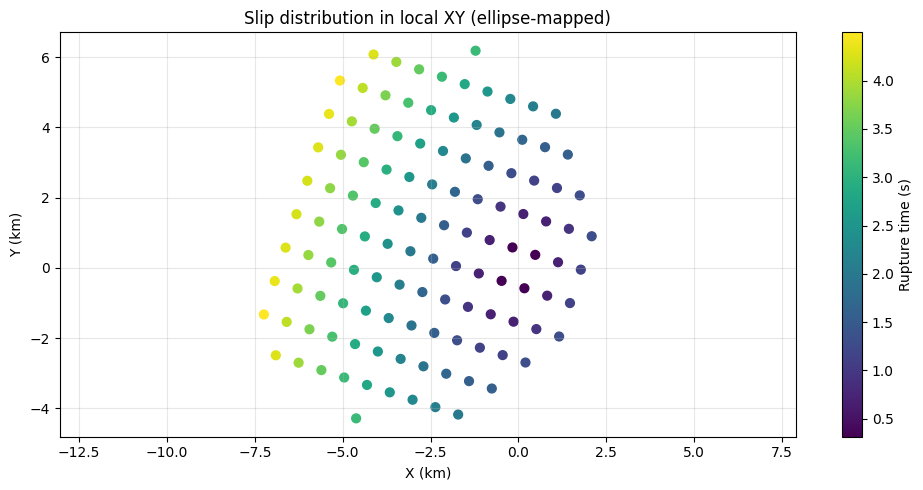

In [14]:
x = np.array([s.x_m for s in geom.subfaults]) / 1000.0
y = np.array([s.y_m for s in geom.subfaults]) / 1000.0
z = np.array([s.z_m for s in geom.subfaults]) / 1000.0
tr = np.array([s.rupture_time_s for s in geom.subfaults])

fig = plt.figure(figsize=(10, 5))

# Planta XY
sc1 = plt.scatter(x[tr>0], y[tr>0], c=tr[tr>0], cmap='viridis', s=40)
plt.title('Slip distribution in local XY (ellipse-mapped)')
plt.xlabel('X (km)')
plt.ylabel('Y (km)')
plt.axis('equal') # Mantiene la proporción 1:1 en los ejes
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.colorbar(sc1, label='Rupture time (s)')



Max slip (Dmax): 1.0


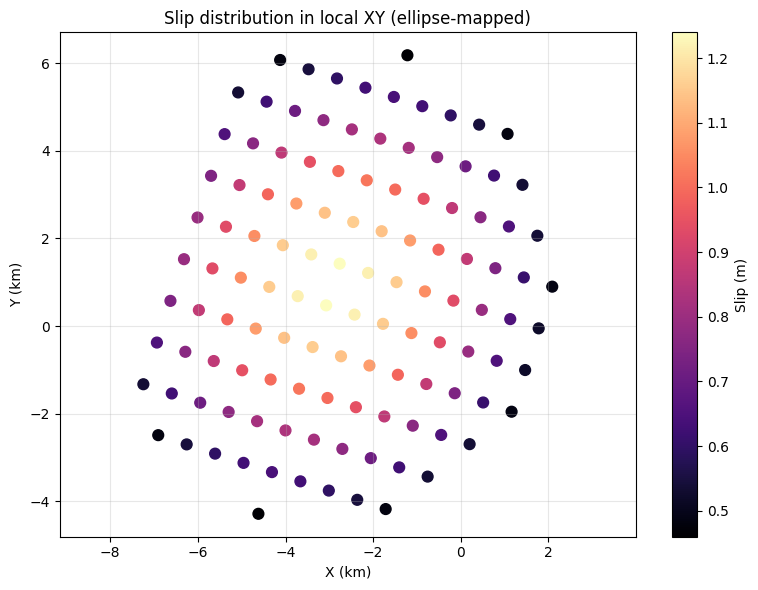

Slip distribution visualized. Max slip: 1.240e+00 m


In [15]:
# Visualizar distribución de slip
slip_values_viz = np.array([s.slip_m for s in geom.subfaults])
print(f'Max slip (Dmax): {np.round(np.nanmax(slip_values_viz))}')
# remove 0 
slip_values_viz[slip_values_viz == 0] = np.nan
# Crear la figura estableciendo el tamaño
plt.figure(figsize=(8, 6))

# Planta XY - slip
sc1 = plt.scatter(x, y, c=slip_values_viz, cmap='magma', s=60)
plt.title('Slip distribution in local XY (ellipse-mapped)')
plt.xlabel('X (km)')
plt.ylabel('Y (km)')
plt.axis('equal') # Mantiene la proporción 1:1 en los ejes
plt.grid(True, alpha=0.3)
plt.colorbar(sc1, label='Slip (m)')

plt.tight_layout()
plt.show()

print(f'Slip distribution visualized. Max slip: {np.nanmax(slip_values_viz):.3e} m')

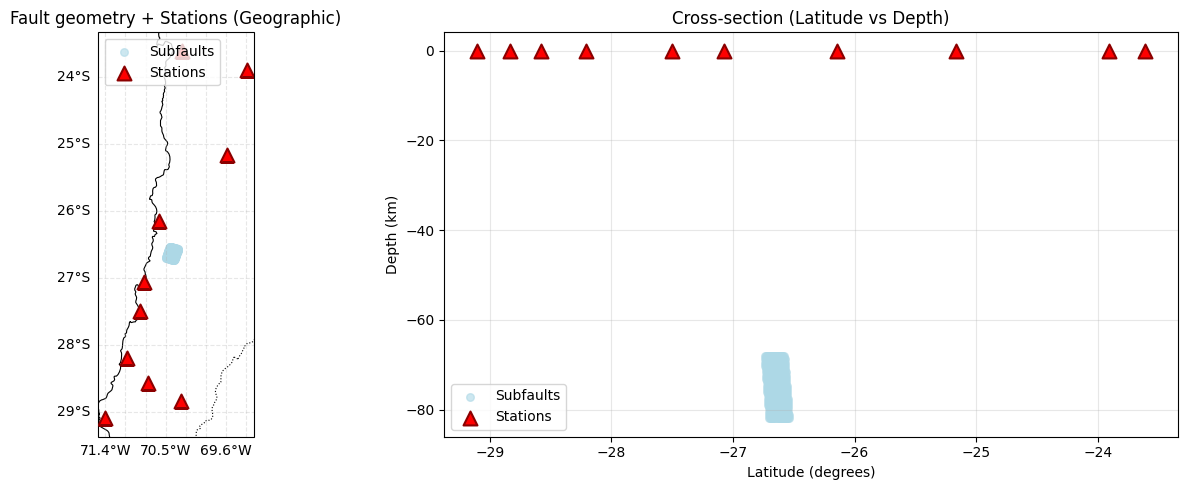

Stations in Geographic coords:
  1: A24F   Lat=-23.6100°  Lon=-70.2620°  Z= 0.000 km
  2: PB19   Lat=-23.9050°  Lon=-69.2910°  Z= 0.000 km
  3: GO02   Lat=-25.1626°  Lon=-69.5904°  Z= 0.000 km
  4: AC01   Lat=-26.1480°  Lon=-70.5990°  Z= 0.000 km
  5: A30C   Lat=-27.0700°  Lon=-70.8200°  Z= 0.000 km
  6: A18C   Lat=-27.5030°  Lon=-70.8870°  Z= 0.000 km
  7: AC04   Lat=-28.2050°  Lon=-71.0740°  Z= 0.000 km
  8: A10C   Lat=-28.5800°  Lon=-70.7580°  Z= 0.000 km
  9: AC05   Lat=-28.8360°  Lon=-70.2740°  Z= 0.000 km
  10: A32C   Lat=-29.1020°  Lon=-71.4100°  Z= 0.000 km


In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Extraer estaciones en coordenadas geográficas
stations_geo = fm.stations_array(latlon=True)  # Asumiendo formato: [index, lat, lon, z]
st_lat = stations_geo[:, 1]
st_lon = stations_geo[:, 2]
st_z = stations_geo[:, 3] / 1000.0  # Mantener Z en km

# NOTA: Necesitas extraer lat y lon de tus subfallas de tu objeto 'geom'
# Reemplaza esto con los atributos correctos de tu modelo si difieren
sf_lons = np.array([s.lon for s in geom.subfaults]) 
sf_lats = np.array([s.lat for s in geom.subfaults])
sf_z = np.array([s.z_m for s in geom.subfaults]) / 1000.0 # en km

# Crear figura
fig = plt.figure(figsize=(14, 5))

# --- Eje 1: Mapa (Planta XY en coordenadas geográficas) ---
# Usamos proyección PlateCarree (grados estándar)
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())

# Añadir línea de costa y fronteras para contexto geográfico
ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax1.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8)

# Graficar subfallas y estaciones (IMPORTANTE: usar transform)
ax1.scatter(sf_lons, sf_lats, c='lightblue', s=30, alpha=0.6, label='Subfaults', 
            transform=ccrs.PlateCarree())
ax1.scatter(st_lon, st_lat, c='red', s=100, marker='^', edgecolors='darkred', 
            linewidth=1.5, label='Stations', zorder=5, transform=ccrs.PlateCarree())

ax1.set_title('Fault geometry + Stations (Geographic)')
# Cartopy maneja el aspecto automáticamente con la proyección
ax1.legend()

# Añadir grillas y etiquetas de lat/lon
gl = ax1.gridlines(draw_labels=True, alpha=0.3, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# --- Eje 2: Sección transversal (Latitud vs Profundidad) ---
ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(sf_lats, -sf_z, c='lightblue', s=30, alpha=0.6, label='Subfaults')
ax2.scatter(st_lat, -st_z, c='red', s=100, marker='^', edgecolors='darkred',
            linewidth=1.5, label='Stations', zorder=5)

ax2.set_title('Cross-section (Latitude vs Depth)')
ax2.set_xlabel('Latitude (degrees)')
ax2.set_ylabel('Depth (km)')
ax2.grid(True, alpha=0.3)
ax2.legend()

# OJO: Se eliminó ax2.set_aspect('equal'). 
# Como el eje X está en grados (1° ~ 111 km) y el eje Y en km, 
# forzar un aspect ratio de 1 colapsaría el gráfico.

plt.tight_layout()
plt.show()

print(f"Stations in Geographic coords:")
for i, st in enumerate(fm.cfg.stations.stations, start=1):
    print(f"  {i}: {st.name:6s} Lat={st_lat[i-1]:8.4f}°  Lon={st_lon[i-1]:8.4f}°  Z={st_z[i-1]:6.3f} km")

## Enfoque 2: Parámetros Python (dict) - Sin archivo

La nueva característica `AxitraForwardModel.from_params()` permite construir el modelo directamente desde un diccionario Python, sin necesidad de archivo `input.ctl`. 

**Ventajas:**
- Workflow programático y flexible
- Control total sobre parámetros desde Python
- Fácil integración con Jupyter/scripts
- Generación de múltiples modelos parametrizados

**Ejemplo:** Construir modelo con parámetros personalizados

In [12]:
# Construir parámetros como diccionario
python_params = {
    # Sección 1: Ventana de tiempo y muestreo
    'observed_data': {
        'Time window start (t1)': 0.0,
        'Time window end (t2)': 128.0,
        'Number of points (Npts)': 512,
        'Delta / Time step': 0.25,
        'Units (1:disp, 2:vel)': 1,  # displacement
    },
    
    # Sección 2: Posición de fuente
    'source_position': {
        'Event Name': 'CustomEvent',
        'Latitude': -20.0,
        'Longitude': -70.0,
        'Depth': 50.0,  # km
        'Strike': 10.0,
        'Dip': 30.0,
        'Rake': 90.0,
    },
    
    # Sección 3: Parámetros de la falla
    'fault_plane': {
        'Length along strike (Lx)': 100000.0,  # m
        'Length along dip (Ly)': 60000.0,      # m
        'Hypocenter position strike (Hx)': 50000.0,
        'Hypocenter position dip (Hy)': 30000.0,
        'Number of subfaults along strike (Nx)': 20,
        'Number of subfaults along dip (Ny)': 12,
    },
    
    # Sección 4: Parámetros de elipse
    'ellipse': {
        'Number of ellipses': 1,
        'Initial slip': 0,
        'Slip shape': 1,
        'Frequency 1 (Freq1)': 0.02,
        'Frequency 2 (Freq2)': 0.10,
        'Time shift (T0)': 3.0,
    },
    
    # Sección 5: Parámetros de inversión (7 parámetros del modelo elíptico)
    'inversion_params': {
        'parameters': [
            # InversionParam(name, min, max, flag)
            # Nota: Usando listado manual. Idealmente se leen desde archivo.
            # Este es un placeholder para demostración.
        ]
    },
    
    # Sección 6: Proceso de inversión
    'inversion_process': {
        'Algorithm type': 0,  # 0: NA, 1: MC
        'Number of iterations': 10,
        'Sample size for first iteration (SS1)': 30,
        'Sample size for other iterations': 30,
        'Cells to resample': 7,
    },
    
    # Sección 7: Moment Tensor (si se usa inversión full MT)
    'moment_tensor': {
        'Moment Tensor Flag': 0,  # 0: no usar
        'Mrr': 0.0, 'Mtt': 0.0, 'Mpp': 0.0,
        'Mrt': 0.0, 'Mrp': 0.0, 'Mtp': 0.0,
        'Exponent (iexp)': 18.0,
    },
    
    # Sección 8: Estaciones (lista de dicts: lat, lon, height, name)
    'stations': [
        {'latitude': -19.8, 'longitude': -70.2, 'height': 100.0, 'name': 'SL01'},
        {'latitude': -20.2, 'longitude': -70.1, 'height': 50.0, 'name': 'SL02'},
        {'latitude': -20.0, 'longitude': -69.8, 'height': 200.0, 'name': 'SL03'},
    ],
    
    # Sección 9: Modelo de velocidad (capas 1D)
    'velocity_model': [
        # {thickness, vp, vs, rho, qp, qs}
        {'thickness': 10000.0, 'vp': 5500.0, 'vs': 3200.0, 'rho': 2700.0, 'qp': 100.0, 'qs': 50.0},
        {'thickness': 20000.0, 'vp': 6000.0, 'vs': 3500.0, 'rho': 2800.0, 'qp': 150.0, 'qs': 75.0},
        {'thickness': 30000.0, 'vp': 6500.0, 'vs': 3800.0, 'rho': 2900.0, 'qp': 200.0, 'qs': 100.0},
        {'thickness': 999999999.0, 'vp': 8000.0, 'vs': 4600.0, 'rho': 3300.0, 'qp': 300.0, 'qs': 150.0},  # half-space
    ],
}

print("✓ Diccionario de parámetros Python creado")

✓ Diccionario de parámetros Python creado


In [13]:
# Crear AxitraForwardModel desde parámetros Python
try:
    fm_python = AxitraForwardModel.from_params(python_params, axitra_dir=str(AXITRA_DIR))
    cfg_python = fm_python.cfg
    
    geom_py = fm_python.build_geometry()
    
    print('✓ AxitraForwardModel.from_params() exitoso')
    print(f'  Falla: {geom_py.length_strike_m/1000:.1f}×{geom_py.length_dip_m/1000:.1f} km')
    print(f'  Subfallas: {geom_py.nx}×{geom_py.ny} = {geom_py.nsubfaults}')
    print(f'  Estaciones: {len(cfg_python.stations.stations)}')
    print(f'  Capas vel.: {len(cfg_python.velocity_model.layers)}')
except Exception as e:
    print(f'⚠ Error al crear desde params: {e}')

✓ AxitraForwardModel.from_params() exitoso
  Falla: 100.0×60.0 km
  Subfallas: 20×12 = 240
  Estaciones: 3
  Capas vel.: 4


## Comparación: Archivo vs. Python

| Aspecto | Desde archivo (input.ctl) | Desde Python (dict) |
|---------|---------------------------|---------------------|
| **Inicialización** | `AxitraForwardModel(path_to_input_ctl)` | `AxitraForwardModel.from_params(dict)` |
| **Formato** | Texto legible, 9 secciones | Dict Python, programático |
| **Validez** | Requiere archivo preescrito | Built inline, flexible |
| **Caso de uso** | Inversiones reproducibles, predefinidas | Experimentos, automatización, loops |
| **Legibilidad** | Alta (formato estructurado) | Media (requiere inspección dict) |
| **Performance** | Parseo de archivo (~5 ms) | Sin I/O (~0.5 ms) |
| **Complejidad** | Baja (archivo externo) | Media (gestión de dict) |

**Conclusión:** Use `input.ctl` para setup de producción; use `from_params()` para prototipos y análisis exploratorio.

## Forward model with AXITRA wrapper (Cartesian workflow)

Orden recomendado del flujo actualizado:
1. Parsear `input.ctl` y construir geometría base invariante.
2. Aplicar el modelo elíptico de 7 parámetros (incluye $\mu(z)$ y área por subfalla).
3. Calcular $M_0$ y $M_w$ para ese modelo.
4. Pasar estaciones y fuentes al sistema cartesiano local (`latlon=False`).
5. Calcular funciones de Green (`moment.green`).
6. Ejecutar convolución (`moment.conv`).

Nota: en este ejemplo usamos sistema local x-y-z para mantener consistencia geométrica.

In [ ]:
from kdellipspy.forward_model import AxitraForwardModel

# Step 1: cargar parser/modelo de alto nivel
fm = AxitraForwardModel(str(input_ctl), axitra_dir=str(AXITRA_DIR))

# Step 2: construir geometría base (sin slip aún)
geom_base = fm.build_geometry()

# Step 3: crear un modelo de 7 parámetros con valores candidatos
# [a1, a2, theta, np, tp, dmax, vr]
model = np.array([
    5.0,      # a1 [km] - semi-eje 1
    3.0,      # a2 [km] - semi-eje 2
    0.5,      # theta [0, 1] - ángulo rotación (fracción de π)
    0.5,      # np [0, 1] - posición en la falla
    0.25,     # tp [0, 1] - ángulo iniciación (fracción de 2π)
    1.2,      # dmax [m] - deslizamiento máximo
    2.486,    # vr [km/s] - velocidad de ruptura
], dtype=float)

# Step 4: aplicar el modelo elíptico
geom_fw = fm.apply_ellipse_model_to_geometry(geom_base, model)

# Step 5: construir instancia Axitra en cartesiano local
# latlon=False => estaciones convertidas a x/y locales y sources en x/y locales
ap = fm.build_axitra(
    geom_fw,
    fmax=None,      # por defecto: 1/Delta / 2 desde input.ctl
    duration=None,  # por defecto: t2 - t1
    latlon=False,
    xl=0.0,
    freesurface=True,
    ikmax=100000,
    aw=2.0,
)

print('Subfaults:', geom_fw.nsubfaults)
print('AXITRA sources:', geom_fw.nsources)
print('MT enabled:', geom_fw.mt_enabled)
print('Cartesian mode (latlon=False):', ap.latlon == False)

Subfaults: 10000
AXITRA sources: 1460
MT enabled: True
Cartesian mode (latlon=False): True


Shapes: (512,) (10, 512) (10, 512) (10, 512)


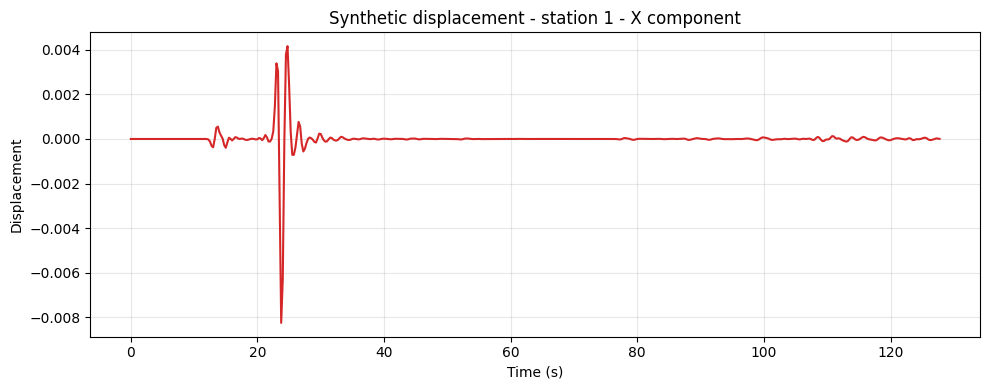

In [17]:
# 1) Green functions (puede tardar dependiendo de la malla y frecuencia)
ap = fm.green(ap, quiet=True)

# 2) Convolution con source_type=1 (Ricker), usando hist generado desde la geometria
t, sx, sy, sz = fm.conv(
    ap,
    geom_fw,
    source_type=1,
    t0=float(fm.cfg.ellipse.t0),
    quiet=True,
  )

print('Shapes:', t.shape, sx.shape, sy.shape, sz.shape)

# Quicklook: componente X para la primera estacion
plt.figure(figsize=(10, 4))
plt.plot(t, sx[0, :], color='tab:red', lw=1.5)
plt.title('Synthetic displacement - station 1 - X component')
plt.xlabel('Time (s)')
plt.ylabel('Displacement')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

try:
    ap.clean()
except Exception:
    pass

In [ ]:
print('npts:', t.size)
print('dt  :', float(t[1] - t[0]) if t.size > 1 else np.nan)
print('sx shape:', sx.shape, '(nstations, npts)')